## Ch4. Time series features Forecasting: Principles & Practice (Python Edition) Extracted from: fpppy-04-features.qmd

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## [Slide 1] Chapter Overview

In [2]:
import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## [Slide 3] 4.1 Simple Statistics

In [3]:
aus_tourism = pd.read_csv("data/aus_tourism.csv",
                           parse_dates=["ds"])

summary_stats = tsf.tsfeatures(
    aus_tourism,
    freq=4,
    features=[tsf.statistics],
    scale=False
)
summary_stats[["unique_id","min","p25","median","p75","max"]].head(10)

,unique_id,min,p25,median,p75,max
0,Adelaide Hills-South Australia-Business,0.000000,0.000000,1.255434,3.920368,28.601515
1,Adelaide Hills-South Australia-Holiday,0.000000,5.767673,8.515966,14.059997,35.751337
2,Adelaide Hills-South Australia-Other,0.000000,0.000000,0.907595,2.093167,8.953163
3,Adelaide Hills-South Australia-Visiting,0.777638,8.907923,12.206619,16.806339,81.102109
4,Adelaide-South Australia-Business,68.725393,133.893462,152.576618,176.935536,242.494368
5,Adelaide-South Australia-Holiday,108.033040,134.626822,153.945007,172.256676,223.557406
6,Adelaide-South Australia-Other,25.901846,43.865901,53.809463,62.523135,107.494657
7,Adelaide-South Australia-Visiting,136.611154,178.915998,205.581736,229.299111,269.535618
8,Alice Springs-Northern Territory-Business,1.008425,9.133369,13.324161,18.456365,34.077065
9,Alice Springs-Northern Territory-Holiday,2.808555,16.850803,31.523782,44.784402,76.541382


## [Slide 5] 4.2 ACF Features

In [4]:
acf_feat = tsf.tsfeatures(
    aus_tourism,
    freq=4,
    features=[tsf.acf_features]
)
acf_feat.head(10).iloc[:, :5]

,unique_id,x_acf1,x_acf10,diff1_acf1,diff1_acf10
0,Adelaide Hills-South Australia-Business,0.070915,0.134473,-0.579504,0.414537
1,Adelaide Hills-South Australia-Holiday,0.131320,0.312710,-0.536153,0.500211
2,Adelaide Hills-South Australia-Other,0.261143,0.330169,-0.253227,0.317087
3,Adelaide Hills-South Australia-Visiting,0.139167,0.116787,-0.472006,0.238615
4,Adelaide-South Australia-Business,0.033271,0.130646,-0.519622,0.462537
5,Adelaide-South Australia-Holiday,0.045570,0.371898,-0.342625,0.614365
6,Adelaide-South Australia-Other,0.516806,1.153598,-0.408620,0.382891
7,Adelaide-South Australia-Visiting,0.068365,0.294237,-0.393654,0.452291
8,Alice Springs-Northern Territory-Business,0.217424,0.366634,-0.499585,0.380557
9,Alice Springs-Northern Territory-Holiday,-0.006605,2.113374,-0.152790,2.113436


## [Slide 7] 4.3 STL Decomposition Review

In [5]:
y = pd.read_csv("data/AirPassengers.csv", parse_dates=["ds"]).set_index("ds")["y"]


In [6]:
from statsmodels.tsa.seasonal import STL
import numpy as np

stl = STL(y, period=12, robust=True)
res = stl.fit()

Components: res.trend, res.seasonal, res.resid

## [Slide 9] 4.3 Trend Strength F_T and Seasonal Strength F_S

In [7]:
def compute_stl_features(y, period=12):
    res = STL(y, period=period, robust=True).fit()
    ft = max(0, 1 - np.var(res.resid) /
                   np.var(res.trend + res.resid))
    fs = max(0, 1 - np.var(res.resid) /
                   np.var(res.seasonal + res.resid))
    return {"trend_strength": ft, "seasonal_strength": fs}

## [Slide 11] 4.3 Computing STL Features with tsfeatures

In [8]:
stl_feat = tsf.tsfeatures(
    aus_tourism,
    freq=4,
    features=[tsf.stl_features]
)
stl_feat.head(10).iloc[:, :5]

,unique_id,nperiods,seasonal_period,trend,spike
0,Adelaide Hills-South Australia-Business,1,4,0.459551,0.000322
1,Adelaide Hills-South Australia-Holiday,1,4,0.531073,0.000105
2,Adelaide Hills-South Australia-Other,1,4,0.589967,0.000053
3,Adelaide Hills-South Australia-Visiting,1,4,0.487016,0.000580
4,Adelaide-South Australia-Business,1,4,0.461801,0.000097
5,Adelaide-South Australia-Holiday,1,4,0.577813,0.000017
6,Adelaide-South Australia-Other,1,4,0.746461,0.000024
7,Adelaide-South Australia-Visiting,1,4,0.448953,0.000048
8,Alice Springs-Northern Territory-Business,1,4,0.551599,0.000052
9,Alice Springs-Northern Territory-Holiday,1,4,0.379298,0.000007


## [Slide 13] 4.3 Visualising STL Features by State

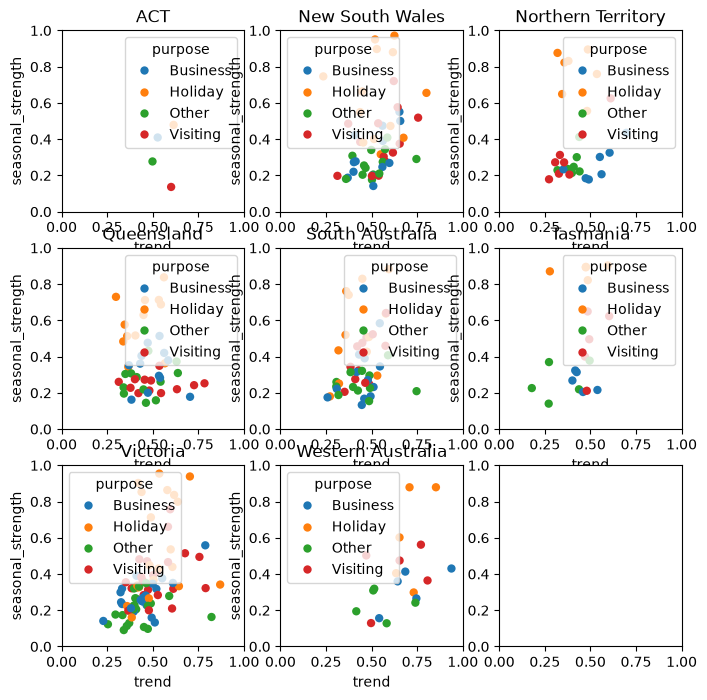

In [9]:
df = (
    stl_feat["unique_id"].str.split("-", expand=True)
    .rename(columns={0:"region", 1:"state", 2:"purpose"})
    .join(stl_feat)
)
fig, axs = plt.subplots(3, 3, figsize=(8, 8))
axs = axs.flatten()
for ax, (state, state_df) in zip(axs, df.groupby('state')):
    sns.scatterplot(x="trend", y="seasonal_strength",
        hue="purpose", edgecolor="none",
        data=state_df, ax=ax)
    ax.set(title=state, xlim=(0,1), ylim=(0,1))

## [Slide 16] 4.4 Computing All Features

In [10]:
all_features = [
    tsf.acf_features,
    tsf.arch_stat,
    tsf.crossing_points,
    tsf.entropy,
    tsf.flat_spots,
    tsf.heterogeneity,
    tsf.holt_parameters,
    tsf.lumpiness,
    tsf.nonlinearity,
    tsf.pacf_features,
    tsf.stl_features,
    tsf.stability,
    tsf.hw_parameters,
    tsf.unitroot_kpss,
    tsf.unitroot_pp,
    tsf.series_length,
    tsf.hurst,
]
all_feat = tsf.tsfeatures(
    aus_tourism, freq=4, features=all_features
)

## [Slide 18] 4.5 Australian Tourism Dataset

In [11]:
aus_tourism = pd.read_csv("data/aus_tourism.csv",
                           parse_dates=["ds"])

304 unique series

In [12]:
print(aus_tourism["unique_id"].nunique())

304


## [Slide 20] 4.5 Pairwise Feature Plot

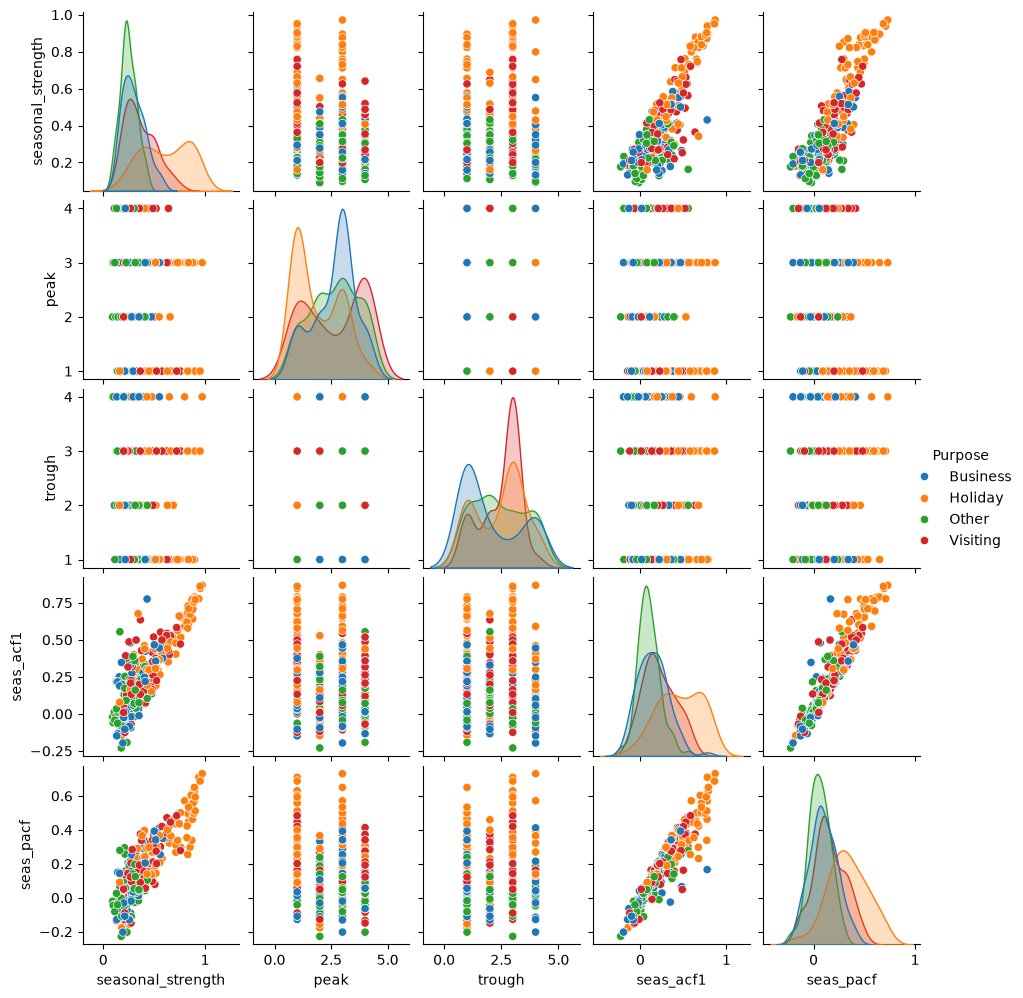

In [13]:
seasonal_feat = all_feat[[
    "unique_id","seasonal_strength","peak","trough",
    "seas_acf1","seas_pacf"
]]
df = (
    seasonal_feat["unique_id"].str.split("-", expand=True)
    .rename(columns={0:"region",1:"state",2:"Purpose"})
    .join(seasonal_feat)
)
g = sns.pairplot(df, hue="Purpose")
g.fig.set_size_inches(10, 10)

## [Slide 22] 4.5 PCA on Feature Matrix

In [14]:
df = (
    all_feat
    .assign(purpose=lambda x:
        x["unique_id"].str.split("-").str[-1])
    .dropna(axis='columns')
)
X = df.drop(columns=["unique_id","purpose"])

pipeline_pca = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=2)),
])
principal_components = pipeline_pca.fit_transform(X)
pca_df = (
    pd.DataFrame(principal_components,
                 columns=["PC1","PC2"])
    .join(df[["unique_id","purpose"]])
)

## [Slide 24] 4.5 PCA Results

[Text(0.5, 1.0, 'PCA of Features'),
 Text(0.5, 0, 'Principal Component 1'),
 Text(0, 0.5, 'Principal Component 2')]

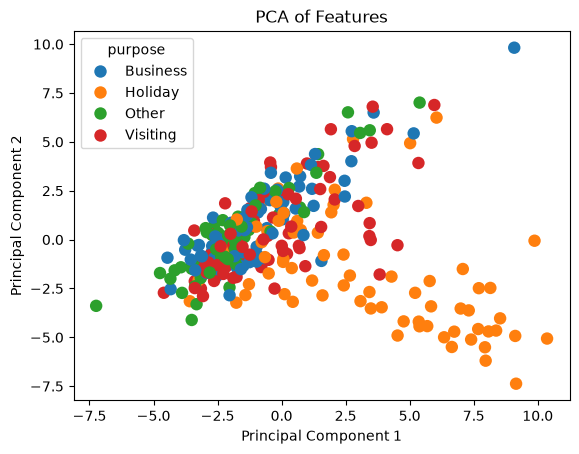

In [15]:
fig, ax = plt.subplots()
sns.scatterplot(x="PC1", y="PC2", s=80,
    hue="purpose", edgecolor="none",
    data=pca_df, ax=ax)
ax.set(title="PCA of Features",
       xlabel="Principal Component 1",
       ylabel="Principal Component 2")

## [Slide 26] 4.5 Feature-Based Outlier Detection

In [16]:
lof = LocalOutlierFactor(n_neighbors=10).fit(
    pca_df[["PC1","PC2"]]
)
res = pca_df.assign(
    score=lof.negative_outlier_factor_
)

Most negative score = most outlying

In [17]:
selected_ids = (
    res.sort_values("score")["unique_id"].head(3)
)

## [Slide 28] 4.5 Visualising Outlying Series

Text(0.5, 0.01, 'Quarter')

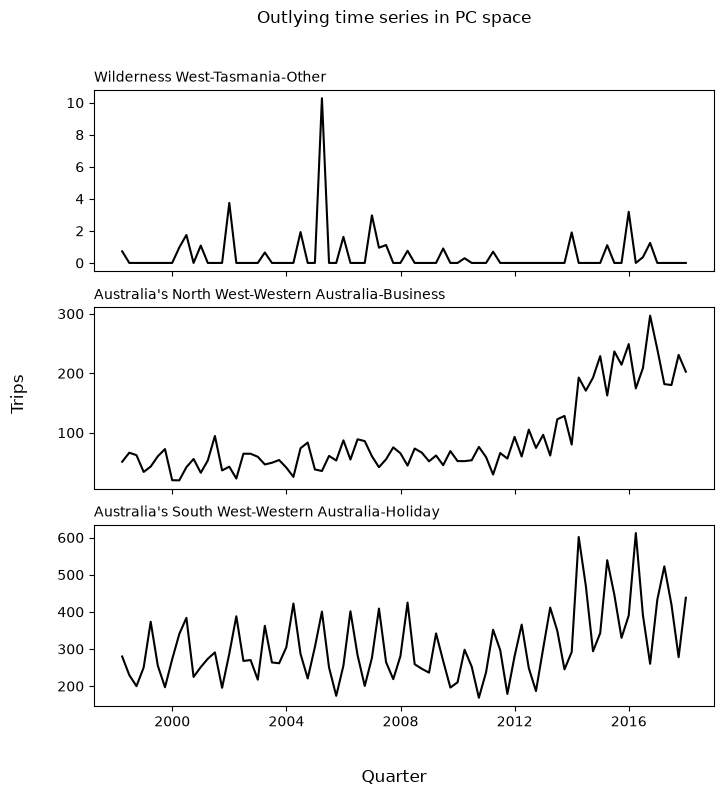

In [18]:
fig, axs = plt.subplots(3, figsize=(8,8), sharex=True)
for ax, uid in zip(axs, selected_ids):
    df_s = aus_tourism.loc[
        lambda x: x["unique_id"] == uid
    ]
    ax.plot(df_s["ds"], df_s["y"], color="k")
    ax.set_title(uid, loc="left", size="medium")

fig.suptitle("Outlying time series in PC space")
fig.supylabel("Trips")
fig.supxlabel("Quarter")